# BERT pretrained model 제작

- 1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행되었다.  
&rarr; 학습된 모델 및 학습과정의 시각화 내역이 제출되었다.  
- 구현한 BERT 모델의 학습이 안정적으로 진행됨을 확인하였다.  
&rarr; 학습진행 과정 중에 MLM, NSP loss의 안정적인 감소가 확인되었다.  
- 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다.  
&rarr; MLM, NSP task의 특징이 잘 반영된 pretrain용 데이터셋 생성과정이 체계적으로 진행되었다.  

# 0. 라이브러리 import 및 setting

In [1]:
# imports
# from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# from torchsummary import summary
from torchinfo import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu126


In [2]:
DATA_DIR = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models')

# 1. 데이터 준비 및 전처리

## 1.1. 데이터 확인

In [3]:
corpus_path = os.path.join(DATA_DIR, 'kowiki.txt')

# kowiki.txt 데이터의 line count 확인
total = 0
with open(corpus_path, 'r') as f:    
    for line in f:
        total += 1    

print(total) # 중간 중간 빈 줄도 있음

3957761


## 1.2. 토크나이저 준비

### 1.2.1. 토크나이저 학습

- Pre-train 모델로 일단 언어의 구조와 맥락을 파악하는 것이 목적이므로, data split을 하지 않고 모든 corpus에 대해 토크나이저 학습을 수행함.

In [4]:
VOCAB_SIZE = 8000

In [5]:
corpus_file = os.path.join(os.getcwd(), 'data/kowiki.txt')
prefix = os.path.join(os.getcwd(), f'data/ko_{VOCAB_SIZE}_mk')

In [17]:
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={VOCAB_SIZE + 7} --model_type=bpe --max_sentence_length=999999 \
         --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] \
            --user_defined_symbols=[SEP],[CLS],[MASK]"
            )

sentencepiece_trainer.cc(177) LOG(INFO) Running command: --input=/home/minkyujeong/work/DeepDive/ch7_bert/data/kowiki.txt --model_prefix=/home/minkyujeong/work/DeepDive/ch7_bert/data/ko_8000_mk --vocab_size=8007 --model_type=bpe --max_sentence_length=999999          --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS]             --user_defined_symbols=[SEP],[CLS],[MASK]
sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/minkyujeong/work/DeepDive/ch7_bert/data/kowiki.txt
  input_format: 
  model_prefix: /home/minkyujeong/work/DeepDive/ch7_bert/data/ko_8000_mk
  model_type: BPE
  vocab_size: 8007
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_s

### 1.2.2. 토크나이저 확인

In [6]:
# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{DATA_DIR}/ko_{VOCAB_SIZE}_mk.model")

True

In [7]:
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print(len(vocab_list))

8000


In [8]:
print(len(vocab))
print(vocab_list[:10])

8007
['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다']


## 1.3. BERT input에 맞게 전처리

### 1.3.1. 마스크 생성

In [9]:
# Masked LM을 위한 코퍼스 생성 메소드
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 idx 분할 (띄어쓰기)
    cand_idx = [] # word 단위의 index array
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"): # u"\u2581"는 단어의 시작을 의미하는 값
            cand_idx[-1].append(i) # 같은 어절 취급
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = [] # mask된 토큰에 대한 idx, 원본 토큰
    for idx_set in cand_idx:
        if len(mask_lms) >= mask_cnt: # 현재 mask된 개수가 mask_cnt와 같거나 커졌다면
            break
        if len(mask_lms) + len(idx_set) > mask_cnt: # 이번에 mask할 개수를 포함해 mask_cnt를 넘기면 skip
            continue
        dice = random.random() # 0과 1 사이의 확률값

        for idx in idx_set:
            masked_token = None
            if dice < 0.8: # 80%는 [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9: # 10%는 유지
                masked_token = tokens[idx] # 어차피 전체 숫자 들어가 있어서 바로 idx 집어 넣으면 해당 토큰 가져올 수 있음
            else: # 10%는 랜덤 토큰
                masked_token = random.choice(vocab_list)

            mask_lms.append({"idx": idx, "label": tokens[idx]})
            tokens[idx] = masked_token
    
    # 순서 정렬 및 mask_idx, mask_label 생성
    mask_lms = sorted(mask_lms, key=lambda x: x["idx"])
    mask_idx = [p['idx'] for p in mask_lms]
    mask_label = [p['label'] for p in mask_lms]

    return tokens, mask_idx, mask_label

In [10]:
# 두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_len = len(tokens_a) + len(tokens_b)
        if total_len <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()        

### 1.3.2. NSP pair 생성

In [11]:

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            # NSP pair 생성
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

### 1.3.3. 데이터셋 완성

In [12]:
# 최종적으로 corpus 가져와서 instance 생성 후 json으로 저장
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ 
    pretrain 데이터 생성 
    vocab: 토크나이저
    in_file: 입력 corpus 경로
    out_file: 결과물 json 경로 
    n_seq
    """
    
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

In [13]:
# MASK_PROB = 0.15
MASK_PROB = 0.35
N_SEQ = 128

pretrain_json_path = os.path.join(os.getcwd(), f'data/pre_train_input_mask_prob-{MASK_PROB}_len-{N_SEQ}.json')

make_pretrain_data(vocab, corpus_file, pretrain_json_path, N_SEQ, mask_prob=MASK_PROB)


  0%|          | 0/3957761 [00:00<?, ?it/s]

In [14]:
# 결과 라인수 확인
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
print(total)



918189


vocab size: 12000일 때 862,285  
vocab size: 8000일 때 918,189

- Vocab 12,000 일 때  
단어가 덜 쪼개지므로, 한 단락(doc) 안에 들어있는 전체 토큰 수가 상대적으로 적어짐 &rarr; 어떤 긴 단락이 총 1,000개 토큰으로 변환되었다면, 128개씩 묶었을 때 약 7~8개의 인스턴스(행)가 생성됨

- Vocab 8,000 일 때  
똑같은 단락인데도 단어가 잘게 파편화되면서 전체 토큰 수가 상대적으로 많아짐 &rarr; 동일한 단락이 총 1,500개 토큰으로 변환된다면, 128개씩 묶었을 때 약 11~12개의 인스턴스(행)가 생성됨


### 1.3.4. 메모리 사용량 최소화 시도 및 data split

In [15]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [16]:
# 128000건만 메모리에 로딩
DATA_TOTAL = 128000
N_TRAIN = int(DATA_TOTAL * 0.9)
N_VAL = DATA_TOTAL - N_TRAIN

print("train dataset 개수: ", N_TRAIN)
print("validation dataset 개수: ", N_VAL)

train dataset 개수:  115200
validation dataset 개수:  12800


In [17]:
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, N_SEQ, count=DATA_TOTAL)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [18]:
# 전체 데이터 개수(128,000)만큼의 인덱스 배열 생성
all_indices = np.arange(DATA_TOTAL)

# 인덱스를 무작위로 뒤섞기 (데이터 분포를 골고루 분산시킴)
np.random.seed(1234) # 실험 재현성을 위해 시드 고정
np.random.shuffle(all_indices)

# 뒤섞인 인덱스를 9:1로 쪼개기
train_indices = all_indices[:N_TRAIN]
val_indices = all_indices[N_TRAIN:]

# load_pre_train_data 결과물 언패킹
enc_all, seg_all = pre_train_inputs
nsp_all, mlm_all = pre_train_labels

# 섞인 인덱스를 사용해 9:1로 데이터 추출
train_enc, val_enc = enc_all[train_indices], enc_all[val_indices]
train_seg, val_seg = seg_all[train_indices], seg_all[val_indices]

train_nsp, val_nsp = nsp_all[train_indices], nsp_all[val_indices]
train_mlm, val_mlm = mlm_all[train_indices], mlm_all[val_indices]

# 최종 확인 출력
print(f"=== [검증] 인덱스 셔플 후 분할 결과 ===")
print(f"Train dataset: {train_enc.shape[0]}건")
print(f"Validate dataset: {val_enc.shape[0]}건")

=== [검증] 인덱스 셔플 후 분할 결과 ===
Train dataset: 115200건
Validate dataset: 12800건


In [19]:
vocab.piece_to_id("[SEP]")

4

In [20]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,   10, 1605, 3599, 1755, 3630,    6,    6,    6,    6, 1135,
           52, 3599,   13,   81,   87, 1501, 1273,   25, 3779, 3873, 3667,
         3631, 3813, 3873, 4196, 3636, 3779, 3601,    6,    6,    6,   33,
           52, 3599,    6,    6,    6,    6, 2780,   14, 1509,  168, 3877,
          414,  165, 1697, 4290, 3873, 3703, 3683,    6,    6,    6,  399,
         1927, 3607,    6,    6,    6,    6,    6,    6,  103, 4313, 4290,
            6,    6,    6,   98, 3878, 3656,  256, 2543,  309,  337, 3735,
          181, 3616, 3603,  489,  376, 3599,    4,    6,    6,  207, 3714,
            6,    6, 6322,  915, 7846, 4346,    6,    6,   37, 3418,  416,
          810, 3666, 3625,    6,    6,    7, 3629,  203,  241, 3602, 1114,
         3724,  788,  243,    6,    6,    6,  663, 1647, 3682, 3682, 3625,
            6, 3008, 3625, 3616,   16, 3599,    4], dtype=int32),
 memmap([   5, 3676,  848, 3784, 1931,    6,    6,    6, 2316, 3619, 3625,
         3617, 3744, 4335,   12, 3

# 2. 학습 준비

In [21]:
# class Config(dict):
#     """
#     json을 config 형태로 사용하기 위한 Class
#     :param dict: config dictionary
#     """
#     __getattr__ = dict.__getitem__
#     __setattr__ = dict.__setitem__

#     @classmethod
#     def load(cls, file):
#         """
#         file에서 Config를 생성 함
#         :param file: filename
#         """
#         with open(file, 'r') as f:
#             config = json.loads(f.read())
#             return Config(config)


In [22]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


## 2.1. 모델 정의

In [23]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs


In [24]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

In [25]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


In [26]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out

In [27]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

In [28]:
class EncoderBlock(nn.Module):
    """
    Encoder Block Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderBlock 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderBlock 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out


In [29]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderBlock(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed


In [30]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super().__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        :return: 순수한 점수 (Logits)
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        # outputs = F.softmax(outputs, dim=-1)
        return outputs


In [31]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_nsp = self.pooled_output(logits_cls)
        # outputs_nsp = F.softmax(logits_nsp, dim=-1)
        # outputs_mlm = F.softmax(logits_lm, dim=-1)
        # return outputs_nsp, outputs_mlm
        return logits_nsp, logits_lm

def build_model_pre_train(config):
    return PreTrainModel(config)


## 2.2. Dataset, DataLoader 생성

In [32]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

# class Vocab:
#     def __init__(self, vocab_size):
#         self.vocab_size = vocab_size
#         self.pad_id = 0

In [33]:
config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 32,
    "dropout": 0.1,
    "d_ff": 256,
    "layernorm_epsilon": 1e-12,
    "n_layer": 3,
    "n_seq": N_SEQ,
    "n_vocab": VOCAB_SIZE,
    "i_pad": vocab.piece_to_id("[PAD]")
})

In [34]:
# vocab = Vocab(config.n_vocab)
# config.n_vocab = vocab.vocab_size
# config.i_pad = vocab.pad_id

In [35]:
BATCH_SIZE = 64 

# 9:1로 쪼개둔 넘파이/memmap 데이터를 토치 텐서로 변환

train_dataset = TensorDataset(
    torch.tensor(train_enc), 
    torch.tensor(train_seg), 
    torch.tensor(train_nsp), 
    torch.tensor(train_mlm)
)

val_dataset = TensorDataset(
    torch.tensor(val_enc), 
    torch.tensor(val_seg), 
    torch.tensor(val_nsp), 
    torch.tensor(val_mlm)
)

# 학습/검증용 데이터로더 구축
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train 배치의 총 개수 (Step 수): {len(train_dataloader)} 개")

Train 배치의 총 개수 (Step 수): 1800 개


# 3. 모델 학습

In [36]:
# def lm_loss(y_true, y_pred):
#     """
#     loss 계산 함수
#     :param y_true: 정답 (bs, n_seq)
#     :param y_pred: 예측 값 (bs, n_seq, n_vocab)
#     """
#     # loss 계산
#     loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
#     # pad(0) 인 부분 mask
#     mask = (y_true != 0).float()
#     loss = loss * mask
#     return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

# 패딩(0)을 제외하고 계산하는 진짜 MLM Loss 함수
def lm_loss(y_pred, y_true):
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    mask = (y_true != 0).float().view(-1)
    loss = loss * mask
    return loss.sum() / (mask.sum() + 1e-9)


작동 방식: 패딩을 제외한 "진짜 의미 있는 단어 토큰의 개수(mask.sum())"로만 손실의 총합(loss.sum())을 나눔  
장점: 한 배치 안에 패딩이 아무리 많든 적든 상관없이, 오롯이 모델이 실제로 맞추거나 틀린 진짜 단어들에 대해서만 마스터 정밀도를 계산

In [37]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy


In [38]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()


In [39]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [40]:
# 모델 생성
pre_train_model = build_model_pre_train(config).to(DEVICE)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(DEVICE)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(DEVICE)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderBlock: 3-2                                [10, 128, 128]       

In [41]:
n_params = sum([p.numel() for p in pre_train_model.parameters() if p.requires_grad])
print("파라미터 수: ", n_params)

파라미터 수:  1455104


In [42]:
EPOCHS = 20

# optimizer
# train_steps = math.ceil(len(pre_train_inputs[0]) / BATCH_SIZE) * EPOCHS
train_steps = len(train_dataloader) * EPOCHS
print("train_steps:", train_steps)

learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
# loss_fn_mlm = nn.CrossEntropyLoss()

train_steps: 36000


In [43]:
# 히스토리에 Validation 지표 기록용 공간 정의
history = {
    'train_loss': [], 'train_nsp_loss': [], 'train_mlm_loss': [], 'train_nsp_acc': [], 'train_mlm_acc': [],
    'val_loss': [], 'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []
}

# Best Model 저장을 위한 최저 Loss 기준점 초기화
best_val_loss = float('inf')

# ------------------------------------------------------------
# 2. 진짜 학습 및 검증 루프 시작 
# ------------------------------------------------------------
for epoch in range(EPOCHS): # 대문자 EPOCHS 변수명 반영
    # --- [TRAIN PHASE] ---
    pre_train_model.train()
    total_loss, total_nsp_loss, total_mlm_loss = 0, 0, 0
    total_nsp_acc, total_mlm_acc = 0, 0

    # tqdm으로 실시간 진행 바 출력
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        # 배치를 꺼낼 때 실시간으로 GPU 이동 (VRAM 안정 장치)
        enc_tokens_batch = batch[0].to(DEVICE)
        segments_batch = batch[1].to(DEVICE)
        labels_nsp_batch = batch[2].to(DEVICE).long()
        labels_mlm_batch = batch[3].to(DEVICE).clamp(0, config.n_vocab - 1).long()

        optimizer.zero_grad()

        # 순전파
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # 오차 계산
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(logits_mlm, labels_mlm_batch) * 20.0
        total_loss_batch = loss_nsp + loss_mlm

        # 역전파 및 가중치 업데이트
        total_loss_batch.backward()
        optimizer.step()
        
        # [선택] 스케줄러가 있다면 여기서 step을 밟아줍니다
        learning_rate_scheduler.step()

        # 통계 누적
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # 정확도 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()
        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # Train 에포크 평균값 계산
    epoch_train_loss = total_loss / len(train_dataloader)
    epoch_train_nsp = total_nsp_loss / len(train_dataloader)
    epoch_train_mlm = total_mlm_loss / len(train_dataloader)
    epoch_train_nsp_acc = total_nsp_acc / len(train_dataloader)
    epoch_train_mlm_acc = total_mlm_acc / len(train_dataloader)


    # --- [VALIDATION PHASE] ---
    pre_train_model.eval()
    val_loss, val_nsp_loss, val_mlm_loss = 0, 0, 0
    val_nsp_acc, val_mlm_acc = 0, 0

    with torch.no_grad():
        for batch in val_dataloader:
            enc_tokens_batch = batch[0].to(DEVICE)
            segments_batch = batch[1].to(DEVICE)
            labels_nsp_batch = batch[2].to(DEVICE).long()
            labels_mlm_batch = batch[3].to(DEVICE).clamp(0, config.n_vocab - 1).long()

            logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = lm_loss(logits_mlm, labels_mlm_batch) * 20.0 # 여기서 가중치 부여함
            total_loss_batch = loss_nsp + loss_mlm

            val_loss += total_loss_batch.item()
            val_nsp_loss += loss_nsp.item()
            val_mlm_loss += loss_mlm.item()

            nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
            mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()
            val_nsp_acc += nsp_acc.item()
            val_mlm_acc += mlm_acc.item()

    # Validation 에포크 평균값 계산
    epoch_val_loss = val_loss / len(val_dataloader)
    epoch_val_nsp = val_nsp_loss / len(val_dataloader)
    epoch_val_mlm = val_mlm_loss / len(val_dataloader)
    epoch_val_nsp_acc = val_nsp_acc / len(val_dataloader)
    epoch_val_mlm_acc = val_mlm_acc / len(val_dataloader)


    # --- [RECORD & SAVE PHASE] ---
    # 히스토리 딕셔너리에 결과 기록
    history['train_loss'].append(epoch_train_loss)
    history['train_nsp_loss'].append(epoch_train_nsp)
    history['train_mlm_loss'].append(epoch_train_mlm)
    history['train_nsp_acc'].append(epoch_train_nsp_acc)
    history['train_mlm_acc'].append(epoch_train_mlm_acc)
    
    history['val_loss'].append(epoch_val_loss)
    history['val_nsp_loss'].append(epoch_val_nsp)
    history['val_mlm_loss'].append(epoch_val_mlm)
    history['val_nsp_acc'].append(epoch_val_nsp_acc)
    history['val_mlm_acc'].append(epoch_val_mlm_acc)

    # 프린트 로그 출력
    print(f"\n📢 Epoch {epoch+1}/{EPOCHS} 결과 요약")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | NSP Loss: {epoch_train_nsp:.4f} | MLM Loss: {epoch_train_mlm:.4f} | NSP Acc: {epoch_train_nsp_acc:.4f} | MLM Acc: {epoch_train_mlm_acc:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | NSP Loss: {epoch_val_nsp:.4f} | MLM Loss: {epoch_val_mlm:.4f} | NSP Acc: {epoch_val_nsp_acc:.4f} | MLM Acc: {epoch_val_mlm_acc:.4f}")

    # 매 에포크 스냅샷 파일 저장
    torch.save(pre_train_model.state_dict(), os.path.join(MODEL_DIR, f"bert_pre_train_epoch_{epoch+1}_mask-{MASK_PROB}.pt"))

    # Best Model 조건 검사 및 저장
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_path = os.path.join(MODEL_DIR, f"best_model_emb-{config.d_ff}_hdim-{config.d_head}_ffdim-{config.d_ff}_nlayer-{config.n_layer}_mask-{MASK_PROB}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': pre_train_model.state_dict(), # 현재 내 모델 변수명에 맞춤
            'optimizer_state_dict': optimizer.state_dict(),
            'best_loss': best_val_loss,
            'history': history                               # 지금까지 쌓인 history가 통째로 드갑니다
        }, best_model_path)
        print(f"🔥 [Best Model] 최저 검증 손실 경신! -> {best_model_path} 저장 완료\n")
    else:
        print(f"💤 [Notice] 최저 기록 경신 실패 (현재 Val Loss: {epoch_val_loss:.4f} / 최저: {best_val_loss:.4f})\n")

Epoch 1/20 [Train]:   0%|          | 0/1800 [00:00<?, ?it/s]


📢 Epoch 1/20 결과 요약
  [Train] Loss: 150.5732 | NSP Loss: 0.6315 | MLM Loss: 149.9416 | NSP Acc: 0.5955 | MLM Acc: 0.0090
  [Val]   Loss: 148.5477 | NSP Loss: 0.6211 | MLM Loss: 147.9266 | NSP Acc: 0.5837 | MLM Acc: 0.0094
🔥 [Best Model] 최저 검증 손실 경신! -> /home/minkyujeong/work/DeepDive/ch7_bert/models/best_model_emb-256_hdim-32_ffdim-256_nlayer-3_mask-0.35.pt 저장 완료



Epoch 2/20 [Train]:   0%|          | 0/1800 [00:00<?, ?it/s]


📢 Epoch 2/20 결과 요약
  [Train] Loss: 148.1698 | NSP Loss: 0.6112 | MLM Loss: 147.5586 | NSP Acc: 0.5960 | MLM Acc: 0.0093
  [Val]   Loss: 147.5148 | NSP Loss: 0.5993 | MLM Loss: 146.9155 | NSP Acc: 0.5970 | MLM Acc: 0.0098
🔥 [Best Model] 최저 검증 손실 경신! -> /home/minkyujeong/work/DeepDive/ch7_bert/models/best_model_emb-256_hdim-32_ffdim-256_nlayer-3_mask-0.35.pt 저장 완료



Epoch 3/20 [Train]:   0%|          | 0/1800 [00:00<?, ?it/s]

...


📢 Epoch 18/20 결과 요약
  [Train] Loss: 126.0438 | NSP Loss: 0.5815 | MLM Loss: 125.4624 | NSP Acc: 0.6117 | MLM Acc: 0.0402
  [Val]   Loss: 124.8728 | NSP Loss: 0.5830 | MLM Loss: 124.2898 | NSP Acc: 0.5962 | MLM Acc: 0.0422
🔥 [Best Model] 최저 검증 손실 경신! -> /home/minkyujeong/work/DeepDive/ch7_bert/models/best_model_emb-256_hdim-32_ffdim-256_nlayer-3_mask-0.35.pt 저장 완료



Epoch 19/20 [Train]:   0%|          | 0/1800 [00:00<?, ?it/s]


📢 Epoch 19/20 결과 요약
  [Train] Loss: 125.3424 | NSP Loss: 0.5814 | MLM Loss: 124.7611 | NSP Acc: 0.6118 | MLM Acc: 0.0409
  [Val]   Loss: 124.0730 | NSP Loss: 0.5818 | MLM Loss: 123.4912 | NSP Acc: 0.5995 | MLM Acc: 0.0430
🔥 [Best Model] 최저 검증 손실 경신! -> /home/minkyujeong/work/DeepDive/ch7_bert/models/best_model_emb-256_hdim-32_ffdim-256_nlayer-3_mask-0.35.pt 저장 완료



Epoch 20/20 [Train]:   0%|          | 0/1800 [00:00<?, ?it/s]


📢 Epoch 20/20 결과 요약
  [Train] Loss: 124.6332 | NSP Loss: 0.5817 | MLM Loss: 124.0515 | NSP Acc: 0.6112 | MLM Acc: 0.0415
  [Val]   Loss: 123.3593 | NSP Loss: 0.5818 | MLM Loss: 122.7775 | NSP Acc: 0.5992 | MLM Acc: 0.0436
🔥 [Best Model] 최저 검증 손실 경신! -> /home/minkyujeong/work/DeepDive/ch7_bert/models/best_model_emb-256_hdim-32_ffdim-256_nlayer-3_mask-0.35.pt 저장 완료



# 4. 결과 확인

In [44]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(16, 6)) # 정보량이 많아지므로 프레임 크기를 넉넉히 잡습니다.

    # ============================================================
    # 1. 왼쪽 칸: Loss 그래프 (Dual Y-Axis)
    # ============================================================
    ax1_loss = plt.subplot(1, 2, 1)
    
    # [왼쪽 Y축] Total Loss 및 MLM Loss (붉은색 & 초록색 계열)
    line1 = ax1_loss.plot(epochs, history['train_loss'], color='crimson', linestyle='--', linewidth=2, label='Train Total Loss')
    line2 = ax1_loss.plot(epochs, history['val_loss'], color='crimson', linestyle='-', linewidth=2, label='Val Total Loss')
    line3 = ax1_loss.plot(epochs, history['train_mlm_loss'], color='forestgreen', linestyle='--', linewidth=1.2, alpha=0.7, label='Train MLM Loss')
    line4 = ax1_loss.plot(epochs, history['val_mlm_loss'], color='forestgreen', linestyle='-', linewidth=1.2, alpha=0.8, label='Val MLM Loss')
    
    ax1_loss.set_xlabel('Epochs', fontsize=10)
    ax1_loss.set_ylabel('Total / MLM Loss Value', color='crimson', fontsize=11, fontweight='bold')
    ax1_loss.tick_params(axis='y', labelcolor='crimson')
    ax1_loss.grid(True, linestyle=':', alpha=0.6)

    # [오른쪽 Y축] NSP Loss 전용 (푸른색 계열)
    ax2_loss = ax1_loss.twinx()  
    line5 = ax2_loss.plot(epochs, history['train_nsp_loss'], color='royalblue', linestyle='--', linewidth=1.5, label='Train NSP Loss')
    line6 = ax2_loss.plot(epochs, history['val_nsp_loss'], color='royalblue', linestyle='-', linewidth=1.5, label='Val NSP Loss')
    
    ax2_loss.set_ylabel('NSP Loss Value', color='royalblue', fontsize=11, fontweight='bold')
    ax2_loss.tick_params(axis='y', labelcolor='royalblue')

    # 범례 합치기
    lines_loss = line1 + line2 + line3 + line4 + line5 + line6
    labels_loss = [l.get_label() for l in lines_loss]
    ax1_loss.legend(lines_loss, labels_loss, loc='upper right', fontsize=8, framealpha=0.8)
    plt.title('BERT Loss Landscapes (Dual Y-Axis)', fontsize=12, fontweight='bold', pad=10)


    # ============================================================
    # 2. 오른쪽 칸: Accuracy 그래프 (Dual Y-Axis 신규 적용)
    # ============================================================
    ax1_acc = plt.subplot(1, 2, 2)
    
    # [왼쪽 Y축] MLM Accuracy 전용 (초록색 계열)
    # 패딩이 빠진 진짜 MLM Acc는 하위권에서 천천히 우상향하므로 독자적인 스케일로 플롯합니다.
    line_a1 = ax1_acc.plot(epochs, history['train_mlm_acc'], color='forestgreen', linestyle='--', linewidth=1.5, label='Train MLM Acc')
    line_a2 = ax1_acc.plot(epochs, history['val_mlm_acc'], color='forestgreen', linestyle='-', linewidth=1.5, label='Val MLM Acc')
    
    ax1_acc.set_xlabel('Epochs', fontsize=10)
    ax1_acc.set_ylabel('MLM Accuracy', color='forestgreen', fontsize=11, fontweight='bold')
    ax1_acc.tick_params(axis='y', labelcolor='forestgreen')
    ax1_acc.grid(True, linestyle=':', alpha=0.6)

    # [오른쪽 Y축] NSP Accuracy 전용 (푸른색 계열)
    # 0.5~0.7 수준의 스케일을 우측 축에 매핑하여 변화량을 역동적으로 포착합니다.
    ax2_acc = ax1_acc.twinx()
    line_a3 = ax2_acc.plot(epochs, history['train_nsp_acc'], color='royalblue', linestyle='--', linewidth=1.5, label='Train NSP Acc')
    line_a4 = ax2_acc.plot(epochs, history['val_nsp_acc'], color='royalblue', linestyle='-', linewidth=1.5, label='Val NSP Acc')
    
    ax2_acc.set_ylabel('NSP Accuracy', color='royalblue', fontsize=11, fontweight='bold')
    ax2_acc.tick_params(axis='y', labelcolor='royalblue')

    # 범례 합치기
    lines_acc = line_a1 + line_a2 + line_a3 + line_a4
    labels_acc = [l.get_label() for l in lines_acc]
    ax1_acc.legend(lines_acc, labels_acc, loc='lower right', fontsize=8, framealpha=0.8)
    plt.title('Pre-training Accuracy Trajectory (Dual Y-Axis)', fontsize=12, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()

In [45]:
# 가장 성능이 좋았던 시점의 가중치 파일 로드
# checkpoint = torch.load("best_transformer_model.pt", map_map=DEVICE)
checkpoint = torch.load(best_model_path, map_location=DEVICE)

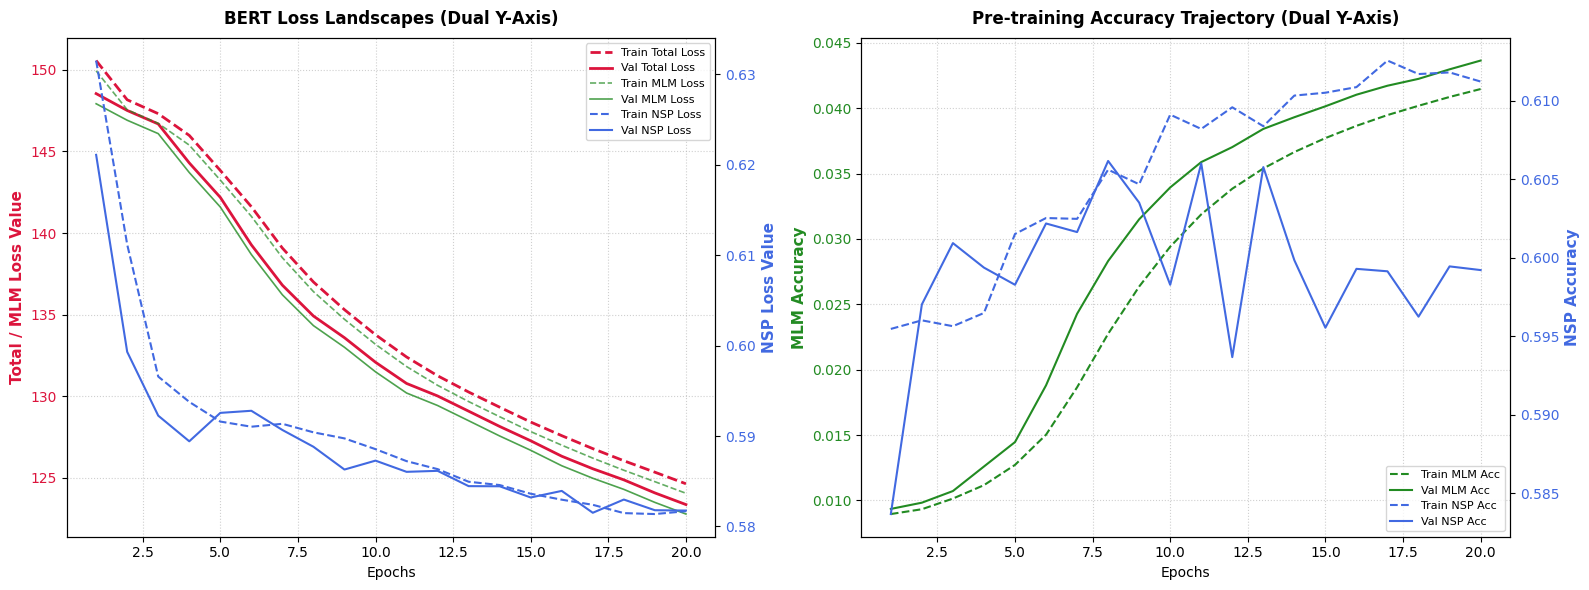

In [46]:
history = checkpoint['history']
plot_history(history)